# Airline Tweet Sentiment and Topic Analysis

This notebook explores the Twitter US Airline Sentiment dataset: which airlines get talked about most, where their customers tweet from, how well sentiment can be predicted from text, and what people are actually complaining about.

It began as a university assignment on applied AI for business. Two methodology issues from the original version are fixed here (see the README for details), the code runs standalone instead of depending on Google Colab, and the charts and writeup are redone from scratch.

In [1]:
import re
import ssl
import warnings
from pathlib import Path

import certifi
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from gensim import corpora, models
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
PALETTE = ["#2E5A87", "#5B9BD5", "#9DC3E6", "#1F3B57", "#7FA8C9", "#3D6E9E"]

## 1. Loading the data and checking its shape

The dataset ships as one CSV with one row per tweet. A quick check of row count, column count, and missing values sets up everything downstream.

In [2]:
df = pd.read_csv("data/tweets.csv")
print(f"Rows: {len(df)}, Columns: {df.shape[1]}")
df.isnull().sum().sort_values(ascending=False).head(5)

Rows: 14640, Columns: 15


negativereason_gold       14608
airline_sentiment_gold    14600
tweet_coord               13621
negativereason             5462
user_timezone              4820
dtype: int64

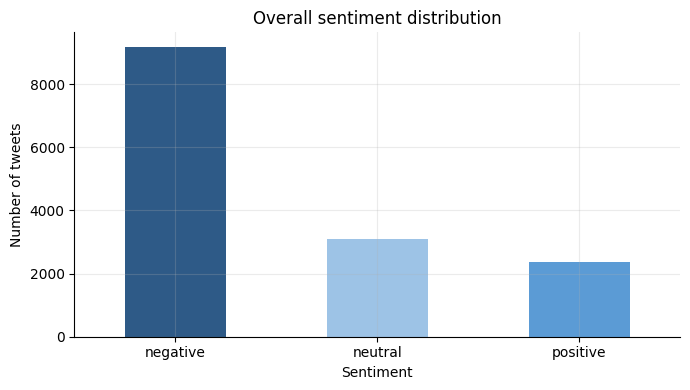

In [3]:
plt.figure(figsize=(7, 4))
df["airline_sentiment"].value_counts().reindex(["negative", "neutral", "positive"]).plot(
    kind="bar", color=[PALETTE[0], PALETTE[2], PALETTE[1]]
)
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.title("Overall sentiment distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Airline popularity by tweet volume

A simple ranking of how many tweets mention each airline, as a rough proxy for how much people are talking about them online.

In [4]:
popularity = df["airline"].value_counts().reset_index()
popularity.columns = ["airline", "tweets"]
popularity

,airline,tweets
0,United,3822
1,US Airways,2913
2,American,2759
3,Southwest,2420
4,Delta,2222
5,Virgin America,504


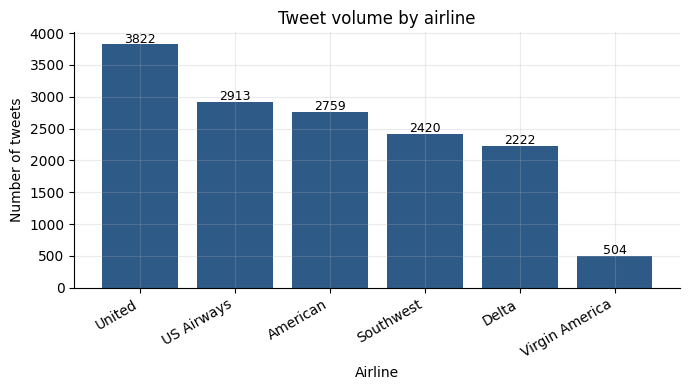

In [5]:
plt.figure(figsize=(7, 4))
plt.bar(popularity["airline"], popularity["tweets"], color=PALETTE[0])
for i, v in enumerate(popularity["tweets"]):
    plt.text(i, v + 30, str(v), ha="center", fontsize=9)
plt.xlabel("Airline")
plt.ylabel("Number of tweets")
plt.title("Tweet volume by airline")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

United draws far more tweets than anyone else, followed by US Airways and American. Virgin America trails the field, though that likely reflects its smaller route network as much as anything about sentiment.

## 3. Where are these customers tweeting from?

The original coursework version matched a state abbreviation as a substring anywhere in the location text, which mistags plenty of real locations ("Orlando" contains "OR", for instance). This version requires the abbreviation to stand alone as its own word, and separately checks full state names and a set of common city names.

In [6]:
STATE_ABBR = {
    "AK", "AL", "AR", "AZ", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "IA", "ID", "IL", "IN",
    "KS", "KY", "LA", "MA", "MD", "ME", "MI", "MN", "MO", "MS", "MT", "NC", "ND", "NE", "NH",
    "NJ", "NM", "NV", "NY", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VA",
    "VT", "WA", "WI", "WV", "WY",
}
STATE_NAME_TO_ABBR = {
    "alabama": "AL", "alaska": "AK", "arizona": "AZ", "arkansas": "AR", "california": "CA",
    "colorado": "CO", "connecticut": "CT", "delaware": "DE", "florida": "FL", "georgia": "GA",
    "hawaii": "HI", "idaho": "ID", "illinois": "IL", "indiana": "IN", "iowa": "IA",
    "kansas": "KS", "kentucky": "KY", "louisiana": "LA", "maine": "ME", "maryland": "MD",
    "massachusetts": "MA", "michigan": "MI", "minnesota": "MN", "mississippi": "MS",
    "missouri": "MO", "montana": "MT", "nebraska": "NE", "nevada": "NV", "new hampshire": "NH",
    "new jersey": "NJ", "new mexico": "NM", "new york": "NY", "north carolina": "NC",
    "north dakota": "ND", "ohio": "OH", "oklahoma": "OK", "oregon": "OR", "pennsylvania": "PA",
    "rhode island": "RI", "south carolina": "SC", "south dakota": "SD", "tennessee": "TN",
    "texas": "TX", "utah": "UT", "vermont": "VT", "virginia": "VA", "washington": "WA",
    "west virginia": "WV", "wisconsin": "WI", "wyoming": "WY",
}
CITY_TO_STATE = {
    "nyc": "NY", "new york city": "NY", "manhattan": "NY", "brooklyn": "NY",
    "los angeles": "CA", "san francisco": "CA", "san diego": "CA", "sf": "CA",
    "chicago": "IL", "boston": "MA", "houston": "TX", "dallas": "TX", "austin": "TX",
    "miami": "FL", "orlando": "FL", "atlanta": "GA", "philadelphia": "PA", "philly": "PA",
    "seattle": "WA", "denver": "CO", "phoenix": "AZ", "charlotte": "NC", "nashville": "TN",
    "washington dc": "DC", "dc": "DC",
}


def get_state(location):
    if not isinstance(location, str) or not location.strip():
        return None
    text = location.strip().lower()
    tokens = re.findall(r"[a-z]+", text)
    for name, abbr in CITY_TO_STATE.items():
        if name in text:
            return abbr
    for name, abbr in STATE_NAME_TO_ABBR.items():
        if name in text:
            return abbr
    for tok in tokens:
        if tok.upper() in STATE_ABBR:
            return tok.upper()
    return None


df_loc = df.dropna(subset=["tweet_location"]).copy()
df_loc["state"] = df_loc["tweet_location"].apply(get_state)
print(f"Matched a real state for {df_loc['state'].notna().mean():.1%} of tweets with a location string")

Matched a real state for 69.5% of tweets with a location string


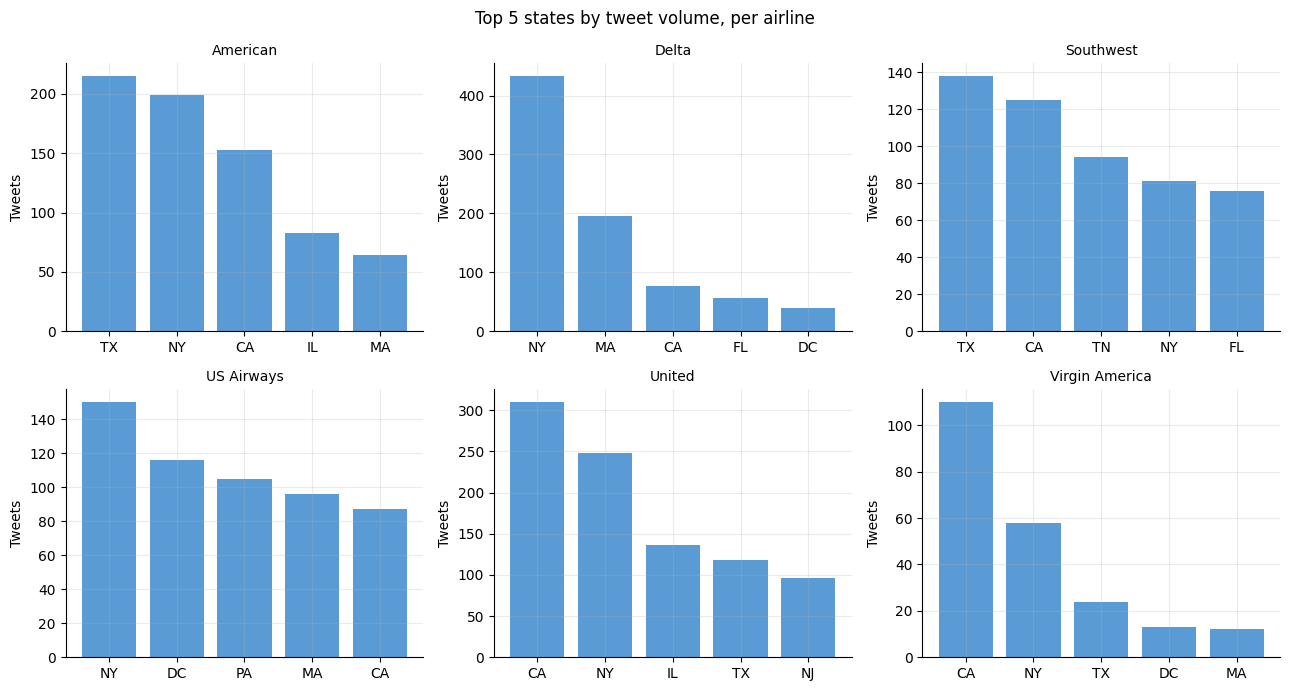

In [7]:
state_popularity = (
    df_loc.dropna(subset=["state"])
    .groupby(["airline", "state"])
    .size()
    .reset_index(name="count")
    .sort_values(["airline", "count"], ascending=[True, False])
)
top_states = state_popularity.groupby("airline").head(5)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (airline, g) in zip(axes.flat, top_states.groupby("airline")):
    ax.bar(g["state"], g["count"], color=PALETTE[1])
    ax.set_title(airline, fontsize=10)
    ax.set_ylabel("Tweets")
fig.suptitle("Top 5 states by tweet volume, per airline")
plt.tight_layout()
plt.show()

Each airline's top states line up with where it actually flies from. Delta skews heavily to New York, United leans towards California, and American and Southwest draw more from Texas.

## 4. Predicting sentiment from tweet text

The original coursework version built its training label as `1 if positive else 0`, which folds neutral tweets in with negative ones before the model ever sees them. Here, all three classes are kept as labeled, and logistic regression and multinomial naive Bayes are compared on precision, recall, and F1 for each class rather than a single accuracy number.

In [8]:
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["airline_sentiment"].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model.fit(X_train_vec, y_train)
lr_pred = lr_model.predict(X_test_vec)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_pred = nb_model.predict(X_test_vec)

print("Logistic Regression\n", classification_report(y_test, lr_pred, target_names=["negative", "neutral", "positive"]))
print("Naive Bayes\n", classification_report(y_test, nb_pred, target_names=["negative", "neutral", "positive"]))

Logistic Regression
               precision    recall  f1-score   support

    negative       0.90      0.79      0.84      1835
     neutral       0.54      0.71      0.61       620
    positive       0.69      0.71      0.70       473

    accuracy                           0.76      2928
   macro avg       0.71      0.74      0.72      2928
weighted avg       0.79      0.76      0.77      2928

Naive Bayes
               precision    recall  f1-score   support

    negative       0.71      0.99      0.83      1835
     neutral       0.76      0.25      0.37       620
    positive       0.84      0.32      0.46       473

    accuracy                           0.72      2928
   macro avg       0.77      0.52      0.55      2928
weighted avg       0.74      0.72      0.67      2928



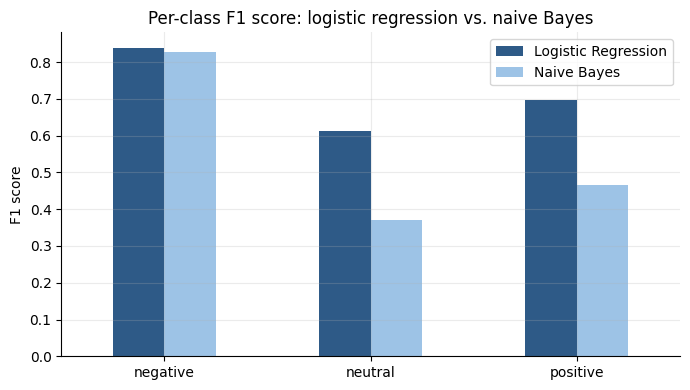

In [9]:
lr_report = classification_report(y_test, lr_pred, target_names=["negative", "neutral", "positive"], output_dict=True)
nb_report = classification_report(y_test, nb_pred, target_names=["negative", "neutral", "positive"], output_dict=True)

metrics_df = pd.DataFrame({
    "Logistic Regression": {k: lr_report[k]["f1-score"] for k in ["negative", "neutral", "positive"]},
    "Naive Bayes": {k: nb_report[k]["f1-score"] for k in ["negative", "neutral", "positive"]},
})
ax = metrics_df.plot(kind="bar", figsize=(7, 4), color=[PALETTE[0], PALETTE[2]])
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1 score: logistic regression vs. naive Bayes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Logistic regression comes out ahead on every class, and the gap is largest for neutral and positive tweets, the two naive Bayes struggles with once it can no longer just call everything negative.

## 5. A lexicon based check: VADER

VADER scores sentiment from a fixed dictionary of word polarities rather than learning from labeled examples, which makes it a useful sanity check against the trained models above.

In [10]:
analyzer = SentimentIntensityAnalyzer()
df["compound"] = df["text"].apply(lambda t: analyzer.polarity_scores(t)["compound"])


def categorize(score):
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"


df["vader_category"] = df["compound"].apply(categorize)
top3 = df["airline"].value_counts().head(3).index.tolist()

vader_summary = {}
for airline in top3:
    sub = df[df["airline"] == airline]
    counts = sub["vader_category"].value_counts(normalize=True)
    vader_summary[airline] = {k: round(float(counts.get(k, 0)), 3) for k in ["positive", "negative", "neutral"]}

vs_df = pd.DataFrame(vader_summary).T[["positive", "negative", "neutral"]]
vs_df

,positive,negative,neutral
United,0.410,0.373,0.217
US Airways,0.361,0.413,0.226
American,0.398,0.388,0.214


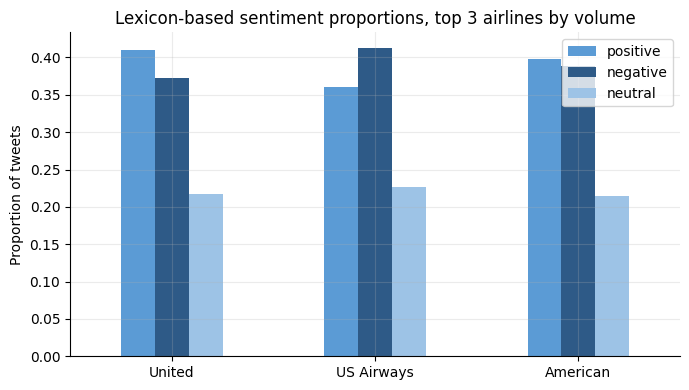

In [11]:
vs_df.plot(kind="bar", figsize=(7, 4), color=[PALETTE[1], PALETTE[0], PALETTE[2]])
plt.ylabel("Proportion of tweets")
plt.title("Lexicon-based sentiment proportions, top 3 airlines by volume")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

US Airways shows the least favorable split of the three most tweeted about airlines, with more negative tweets than positive. United and American both lean positive. This roughly agrees with the trained model's read on the same airlines, which is a reasonable sign that neither approach is picking up noise.

## 6. What are people actually complaining about?

Topic modeling on the nouns in negative tweets surfaces recurring complaint themes without relying on the dataset's own labeled complaint reasons.

In [12]:
stop_words = set(stopwords.words("english"))
negative_tweets = df[df["airline_sentiment"] == "negative"]["text"]


def extract_nouns(text):
    tokens = word_tokenize(re.sub(r"http\S+|@\w+", "", text))
    tagged = pos_tag(tokens)
    return [w.lower() for w, pos in tagged if pos.startswith("NN") and w.lower() not in stop_words and w.isalpha()]


nouns_per_tweet = negative_tweets.apply(extract_nouns)
dictionary = corpora.Dictionary(nouns_per_tweet)
dictionary.filter_extremes(no_below=5, no_above=0.4)
corpus = [dictionary.doc2bow(n) for n in nouns_per_tweet]

NUM_TOPICS = 6
lda_model = models.LdaModel(corpus, num_topics=NUM_TOPICS, id2word=dictionary, passes=15, random_state=42)
for idx in range(NUM_TOPICS):
    words = [w for w, _ in lda_model.show_topic(idx, topn=8)]
    print(f"Topic {idx + 1}: {', '.join(words)}")

Topic 1: flight, plane, gate, delay, hour, agent, bags, seats
Topic 2: flight, luggage, thanks, dfw, days, hrs, today, hours
Topic 3: airline, aa, time, ticket, response, experience, anything, miles
Topic 4: hold, hours, phone, flight, help, call, hour, someone
Topic 5: service, customer, bag, customers, agents, people, baggage, line
Topic 6: flight, cancelled, flights, flightled, tomorrow, seat, hours, flighted


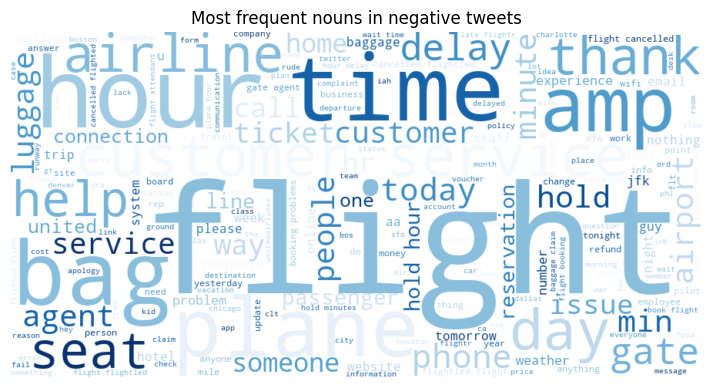

In [13]:
all_nouns_text = " ".join(w for nouns in nouns_per_tweet for w in nouns)
wc = WordCloud(width=900, height=450, background_color="white", colormap="Blues").generate(all_nouns_text)
plt.figure(figsize=(9, 4.5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most frequent nouns in negative tweets")
plt.show()

In [14]:
df["negativereason"].value_counts().head(5)

negativereason
Customer Service Issue    2910
Late Flight               1665
Can't Tell                1190
Cancelled Flight           847
Lost Luggage               724
Name: count, dtype: int64

The topics line up closely with the dataset's own labeled complaint reasons: long holds and phone calls, gate and boarding delays, cancellations, and baggage handling all surface independently from the raw tweet text, not just from the reason field. Customer service issues, late flights, and cancellations account for the bulk of stated complaints, with lost luggage further behind.

## Takeaways

Two things stand out. First, most of the complaint volume is operational friction, being kept waiting on the phone, delays at the gate, mishandled bags, rather than the experience once passengers are actually flying, which points to phone and gate staffing as the more immediate lever. Second, because complaints cluster geographically around each airline's hub cities, service recovery efforts could reasonably be prioritized by location instead of treated uniformly everywhere.

See the [README](README.md) for the full writeup with figures and a discussion of the coursework issues fixed in this version.